In [161]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# kütüphaneleri indirme

In [162]:

base_dir = Path.cwd()
processed_dir = base_dir / "processed"

covid_df = pd.read_csv(processed_dir / "football_eda_ready_complete_fixed_v2.csv")

covid_df["date"] = pd.to_datetime(covid_df["date"], errors="coerce")

covid_df["total_goals"] = covid_df["home_goals"] + covid_df["away_goals"]
covid_df["goal_diff"] = covid_df["home_goals"] - covid_df["away_goals"]

covid_df["home_win"] = (covid_df["result_label"] == "Home Win").astype(int)
covid_df["away_win"] = (covid_df["result_label"] == "Away Win").astype(int)
covid_df["draw"] = (covid_df["result_label"] == "Draw").astype(int)

covid_df["home_points"] = 0
covid_df["away_points"] = 0

covid_df.loc[covid_df["result_label"] == "Home Win", "home_points"] = 3
covid_df.loc[covid_df["result_label"] == "Draw", "home_points"] = 1

covid_df.loc[covid_df["result_label"] == "Away Win", "away_points"] = 3
covid_df.loc[covid_df["result_label"] == "Draw", "away_points"] = 1

covid_df["home_advantage_points"] = covid_df["home_points"] - covid_df["away_points"]

covid_df.shape


(3578, 28)

In [163]:
print("Shape:", covid_df.shape)
print("League count:", covid_df["league"].nunique())
print("Season types:", covid_df["season_type"].unique())
covid_df.head()

Shape: (3578, 28)
League count: 5
Season types: ['covid' 'normal']


,date,league,season,season_type,covid,home_team,away_team,home_goals,away_goals,result,...,ht_away_goals,ht_result,total_goals,goal_diff,home_win,away_win,draw,home_points,away_points,home_advantage_points
0,2020-08-21,Ligue 1,2020_2021,covid,1,Bordeaux,Nantes,0,0,D,...,0.0,D,0,0,0,0,1,1,1,0
1,2020-08-22,Ligue 1,2020_2021,covid,1,Dijon,Angers,0,1,A,...,1.0,A,1,-1,0,1,0,0,3,-3
2,2020-08-22,Ligue 1,2020_2021,covid,1,Lille,Rennes,1,1,D,...,0.0,H,2,0,0,0,1,1,1,0
3,2020-08-23,Ligue 1,2020_2021,covid,1,Lorient,Strasbourg,3,1,H,...,1.0,A,4,2,1,0,0,3,0,3
4,2020-08-23,Ligue 1,2020_2021,covid,1,Monaco,Reims,2,2,D,...,2.0,A,4,0,0,0,1,1,1,0


In [164]:
covid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3578 entries, 0 to 3577
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   3578 non-null   datetime64[ns]
 1   league                 3578 non-null   object        
 2   season                 3578 non-null   object        
 3   season_type            3578 non-null   object        
 4   covid                  3578 non-null   int64         
 5   home_team              3578 non-null   object        
 6   away_team              3578 non-null   object        
 7   home_goals             3578 non-null   int64         
 8   away_goals             3578 non-null   int64         
 9   result                 3578 non-null   object        
 10  home_last3_points      3578 non-null   int64         
 11  away_last3_points      3578 non-null   int64         
 12  result_label           3578 non-null   object        
 13  hom

In [165]:
covid_df.describe(include="all").head()

,date,league,season,season_type,covid,home_team,away_team,home_goals,away_goals,result,...,ht_away_goals,ht_result,total_goals,goal_diff,home_win,away_win,draw,home_points,away_points,home_advantage_points
count,3578,3578,3578,3578,3578.000000,3578,3578,3578.000000,3578.00000,3578,...,3577.000000,3577,3578.000000,3578.000000,3578.000000,3578.000000,3578.000000,3578.000000,3578.000000,3578.000000
unique,NaN,5,2,2,NaN,120,120,NaN,NaN,3,...,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,La Liga,2020_2021,covid,NaN,Crystal Palace,Arsenal,NaN,NaN,H,...,NaN,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,760,1826,1826,NaN,38,38,NaN,NaN,1464,...,NaN,1414,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2022-12-31 07:25:07.210732288,NaN,NaN,NaN,0.510341,NaN,NaN,1.487703,1.32588,NaN,...,0.592116,NaN,2.813583,0.161822,0.409167,0.338737,0.252096,1.479598,1.268306,0.211291


In [166]:
covid_df.isna().sum().sort_values(ascending=False).head() # eksik olanları görmek için


capacity         1153
stadium          1153
ht_away_goals       1
ht_home_goals       1
ht_result           1
dtype: int64

In [167]:
pd.DataFrame({"unique_count": covid_df.nunique(),"missing_count": covid_df.isna().sum(),}).sort_values("missing_count", ascending=False).head(15) # genel veri yapısıyla ilgili analizler


,unique_count,missing_count
capacity,73,1153
stadium,73,1153
ht_away_goals,6,1
ht_home_goals,7,1
ht_result,3,1
covid,2,0
away_team,120,0
home_team,120,0
date,373,0
league,5,0


In [170]:
covid_df["season_type"].value_counts() # kaç tane covid, kaç tane normal season var


season_type
covid     1826
normal    1752
Name: count, dtype: int64

In [169]:
covid_df["result_label"].value_counts()[["Home Win", "Draw", "Away Win"]]


result_label
Home Win    1464
Draw         902
Away Win    1212
Name: count, dtype: int64

In [171]:
covid_df.groupby(["league", "season_type"]).size()


league          season_type
Bundesliga      covid          306
                normal         306
La Liga         covid          380
                normal         380
Ligue 1         covid          380
                normal         306
Premier League  covid          380
                normal         380
Serie A         covid          380
                normal         380
dtype: int64

In [172]:
numeric_cols = ["home_goals", "away_goals", "total_goals", "goal_diff"]
covid_df[numeric_cols].describe()


,home_goals,away_goals,total_goals,goal_diff
count,3578.000000,3578.00000,3578.000000,3578.000000
mean,1.487703,1.32588,2.813583,0.161822
std,1.288425,1.17280,1.666545,1.814835
min,0.000000,0.00000,0.000000,-7.000000
25%,1.000000,0.00000,2.000000,-1.000000
50%,1.000000,1.00000,3.000000,0.000000
75%,2.000000,2.00000,4.000000,1.000000
max,9.000000,7.00000,9.000000,9.000000


In [173]:
covid_df.groupby("league")[["home_goals", "away_goals", "total_goals"]].mean().round(2) #lig bazlı gol ortalamaları


,home_goals,away_goals,total_goals
league,,,
Bundesliga,1.65,1.43,3.08
La Liga,1.41,1.15,2.56
Ligue 1,1.49,1.37,2.86
Premier League,1.43,1.38,2.81
Serie A,1.48,1.32,2.81


In [174]:
covid_df.pivot_table(index="league",columns="season_type",values="total_goals",aggfunc="mean",).round(2)


season_type,covid,normal
league,,
Bundesliga,3.03,3.13
La Liga,2.51,2.62
Ligue 1,2.76,2.98
Premier League,2.69,2.93
Serie A,3.05,2.56


In [175]:
season_summary = (covid_df.groupby("season_type").agg( matches=("result_label", "size"),avg_home_goals=("home_goals", "mean"), avg_away_goals=("away_goals", "mean"),avg_total_goals=("total_goals", "mean"),avg_goal_diff=("goal_diff", "mean"),).round(3).sort_index())
season_summary


,matches,avg_home_goals,avg_away_goals,avg_total_goals,avg_goal_diff
season_type,,,,,
covid,1826,1.476,1.324,2.801,0.152
normal,1752,1.499,1.328,2.827,0.172


In [176]:
results = (covid_df.groupby(["season_type", "result_label"]).size().unstack(fill_value=0))

results = results.div(results.sum(axis=1), axis=0)
results = results.rename(columns={"H": "Home Win", "D": "Draw", "A": "Away Win"}).round(3)

results
# covid vs normal dönemde oranlar nasıl değişiyor

result_label,Away Win,Draw,Home Win
season_type,,,
covid,0.347,0.255,0.399
normal,0.330,0.249,0.420


In [177]:
home_advantage_summary = (covid_df.groupby("season_type").agg(
        matches=("result_label", "size"),
        home_win_rate=("home_win", "mean"),
        away_win_rate=("away_win", "mean"),
        draw_rate=("draw", "mean"),
        avg_goal_diff=("goal_diff", "mean"),
        home_points_per_match=("home_points", "mean"),
        away_points_per_match=("away_points", "mean"),
        home_advantage_points=("home_advantage_points", "mean")).round(3).sort_index())
home_advantage_summary
#istatistikleri covid vs normal için ayrı ayrı hesaplama


,matches,home_win_rate,away_win_rate,draw_rate,avg_goal_diff,home_points_per_match,away_points_per_match,home_advantage_points
season_type,,,,,,,,
covid,1826,0.399,0.347,0.255,0.152,1.451,1.295,0.156
normal,1752,0.420,0.330,0.249,0.172,1.510,1.241,0.269


In [178]:
league_home_win = (
    covid_df.groupby(["league", "season_type"])["home_win"]
    .mean()
    .unstack()
    .round(3))

league_home_win["delta_normal_minus_covid"] = (league_home_win["normal"] - league_home_win["covid"]).round(3)

league_home_win.sort_values("delta_normal_minus_covid", ascending=False) 
# lig bazlı home win rate karşılaştırma 


season_type,covid,normal,delta_normal_minus_covid
league,,,
Ligue 1,0.374,0.467,0.093
Premier League,0.379,0.408,0.029
La Liga,0.416,0.445,0.029
Serie A,0.408,0.397,-0.011
Bundesliga,0.422,0.386,-0.036


In [179]:
league_advantage = (covid_df.groupby(["league", "season_type"])["home_advantage_points"].mean().unstack().round(3))
league_advantage["delta_normal_minus_covid"] = (league_advantage["normal"] - league_advantage["covid"]).round(3)
league_advantage.sort_values("delta_normal_minus_covid", ascending=False)
#home puan karşılaştırma


season_type,covid,normal,delta_normal_minus_covid
league,,,
Ligue 1,-0.008,0.412,0.420
Premier League,-0.071,0.182,0.253
La Liga,0.355,0.434,0.079
Serie A,0.213,0.237,0.024
Bundesliga,0.324,0.069,-0.255


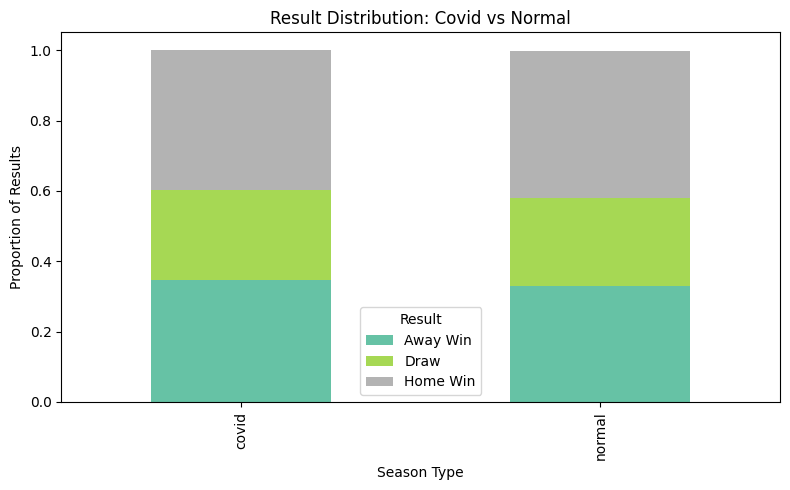

In [180]:
results.plot(kind="bar", stacked=True, colormap="Set2", figsize=(8, 5))

plt.title("Result Distribution: Covid vs Normal")
plt.xlabel("Season Type")
plt.ylabel("Proportion of Results")
plt.legend(title="Result")
plt.tight_layout()
plt.show()


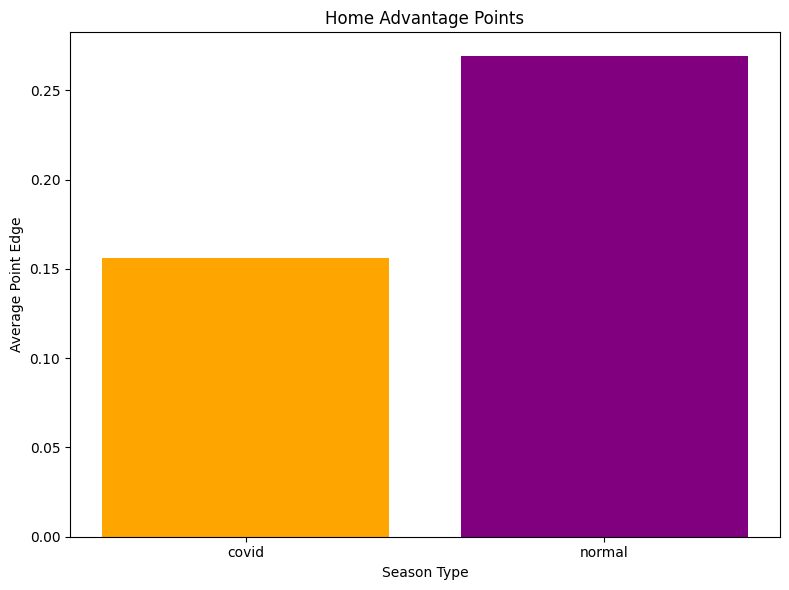

In [181]:
plt.figure(figsize=(8, 6))
plt.bar(home_advantage_summary.index,home_advantage_summary["home_advantage_points"],color=["orange", "purple"])
plt.title("Home Advantage Points")
plt.xlabel("Season Type")
plt.ylabel("Average Point Edge")
plt.tight_layout()
plt.show()


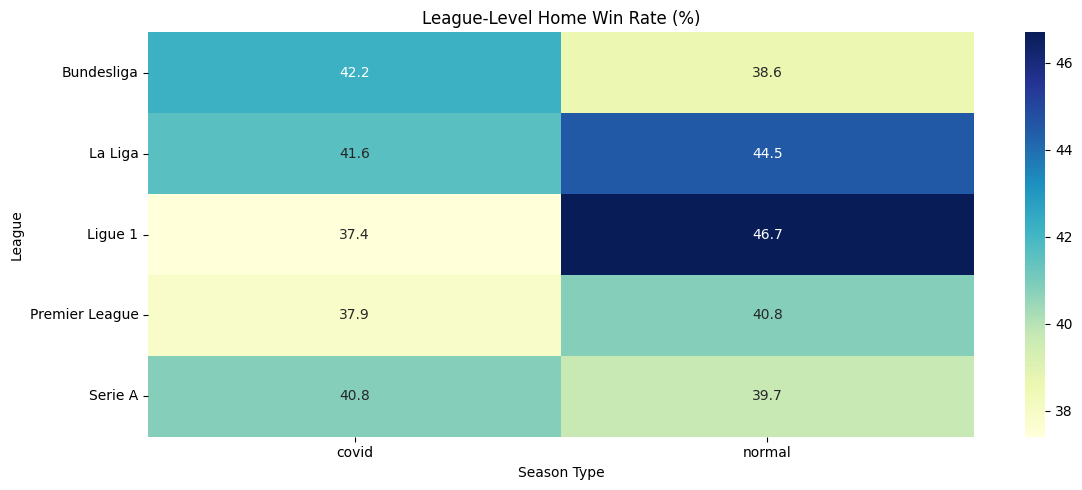

In [182]:
plt.figure(figsize=(12, 5))
sns.heatmap(league_home_win[["covid", "normal"]] * 100,annot=True,fmt=".1f",cmap="YlGnBu")
plt.title("League-Level Home Win Rate (%)")
plt.xlabel("Season Type")
plt.ylabel("League")
plt.tight_layout()
plt.show()
